# MNIST

We will build a classifier for a classic machine learning dataset MNIST.
It consists of scans of handwritten numerals 0–9.
[Here](https://github.com/mbornet-hl/MNIST/blob/master/IMAGES/GROUPS/mnist_v5_MNIST_26001-27000_25x40.png) are images of all the digits.

In [47]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import fetch_openml

In [6]:
mnist = fetch_openml('mnist_784', as_frame=False, cache=False)

In [214]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')
X /= 255.0
X=X.reshape(-1,28,28)
#y=torch.nn.functional.one_hot(torch.tensor(y),10)

In [215]:
train_ds, test_ds = torch.utils.data.random_split(torch.utils.data.StackDataset(X,y), [0.8,0.2])

In [216]:
train_dl = torch.utils.data.DataLoader(train_ds)
test_dl = torch.utils.data.DataLoader(test_ds)

In [219]:
def plot_example(X):
    """Plot the first 5 images and their labels in a row."""
    for i in range(5):
        img = X[i][0].reshape(28,28)
        #label = torch.argmax(X[i][1])
        label = X[i][1]
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(label)

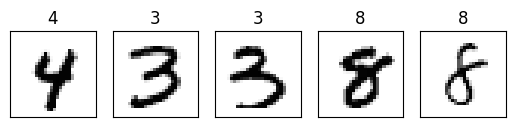

In [220]:
plot_example(train_ds)

A _convolution_ is fancy way of saying we will slide a square across the image and calculate a value for each square. There are some nice animations of [2 dimensional convolutions](https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md).

In [224]:
def conv(ni, nf, ks=3, act=True):
    res = nn.Conv2d(ni, nf, stride=2, kernel_size=ks, padding=ks//2)
    if act: res = nn.Sequential(res, nn.ReLU())
    return res

In [247]:
def simple_cnn():
    return nn.Sequential(
        conv(1, 8, ks=5),
        conv(8, 16),
        conv(16, 32),
        conv(32, 64),
        conv(64, 10, act=False),
        nn.Flatten(),
        #nn.Softmax(dim=1),
    )

Lets make the model, and set up an optimizer to train it.

In [248]:
model = simple_cnn()

In [249]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [250]:
loss_fn = nn.CrossEntropyLoss()

In [232]:
def train_model():
    for batch, (X, y) in enumerate(train_dl):
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred.reshape(1,10), y)
        loss.backward()
        optimizer.step()
        if batch % 1000 == 0:
            print(f"loop: {batch}, loss: {loss:>7f}")

In [253]:
train_model()

loop: 0, loss: 2.356799
loop: 1000, loss: 2.316561
loop: 2000, loss: 2.329134
loop: 3000, loss: 2.536745
loop: 4000, loss: 0.141909
loop: 5000, loss: 0.048193
loop: 6000, loss: 4.427192
loop: 7000, loss: 0.035388
loop: 8000, loss: 0.003356
loop: 9000, loss: 1.915343
loop: 10000, loss: 0.001398
loop: 11000, loss: 0.009522
loop: 12000, loss: 0.000056
loop: 13000, loss: 0.005893
loop: 14000, loss: 0.000291
loop: 15000, loss: 0.053236
loop: 16000, loss: 0.000225
loop: 17000, loss: 0.022147
loop: 18000, loss: 0.012049
loop: 19000, loss: 0.223142
loop: 20000, loss: 0.000251
loop: 21000, loss: 0.003396
loop: 22000, loss: 0.068687
loop: 23000, loss: 0.001410
loop: 24000, loss: 0.000433
loop: 25000, loss: 0.095672
loop: 26000, loss: 0.001701
loop: 27000, loss: 0.000010
loop: 28000, loss: 0.000000
loop: 29000, loss: 0.219263
loop: 30000, loss: 0.028402
loop: 31000, loss: 0.001948
loop: 32000, loss: 0.001751
loop: 33000, loss: 0.034351
loop: 34000, loss: 0.002342
loop: 35000, loss: 0.686316
loop:

In [181]:
def show_model_output(X):
    """Plot the images, their labels and the model guess in a row."""
    for i in range(min(len(X),5)):
        img = X[i][0].reshape(28,28)
        label = X[i][1]
        with torch.no_grad():
            values = model(torch.tensor(img.reshape(1,28,28)))
            guess = torch.argmax(values)
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(f"{label} / {guess}")

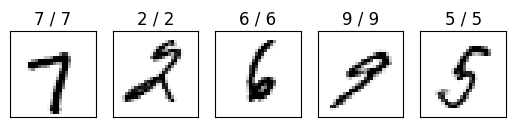

In [254]:
show_model_output(test_ds)

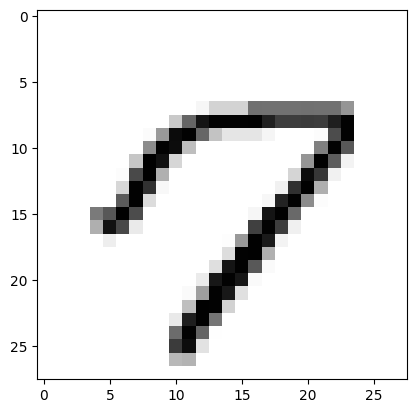

In [256]:
plt.imshow(test_ds[589][0])

In [257]:
model(torch.tensor(test_ds[589][0].reshape(1,28,28)))

tensor([[ 3.3225],
        [-3.1726],
        [-3.5131],
        [-2.3876],
        [-1.4397],
        [ 2.4832],
        [-3.3062],
        [ 7.8255],
        [-2.6706],
        [ 3.1786]], grad_fn=<ViewBackward0>)